# Finite-size corrections with Yeh-Hummer

When performing molecular dynamics simulations with periodic boundary conditions, the calculated diffusion coefficients are affected by finite-size effects. The `kinisi` package includes tools to apply the Yeh-Hummer finite-size correction, which extrapolates the diffusion coefficient to the infinite system size limit.

In this tutorial, we will demonstrate how to use the `YehHummer` class to correct diffusion coefficients obtained from simulations with different box sizes.

<div class="alert alert-info">

**Note**

The Yeh-Hummer correction is based on the work by Yeh & Hummer (J. Phys. Chem. B 2004, 108, 15873-15879). The method assumes that the finite-size effects follow a linear relationship with the inverse box length.
</div>

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipp as sc

from kinisi.yeh_hummer import YehHummer

np.random.seed(42)

## Setting up the data

For this tutorial, we will use the TIP3P water diffusion data from the original Yeh & Hummer paper. This data represents diffusion coefficients calculated from molecular dynamics simulations of water at different box sizes.

For obtaining diffusion coefficients from your simulations, you can use the `kinisi.analyze.DiffusionAnalyzer` (from `DiffusionAnalyzer.D`) by following the steps outlined in the [Diffusion coefficient from a VASP file](./vasp_d.html) tutorial.

In [2]:
# TIP3P water data from Yeh & Hummer paper
box_lengths = np.array([18.58, 23.42, 29.51, 37.19, 46.86])  # Angstroms
D_values = np.array([4.884e-5, 5.123e-5, 5.315e-5, 5.466e-5, 5.590e-5])  # cm^2/s
D_errors = np.array([0.032e-5, 0.027e-5, 0.014e-5, 0.011e-5, 0.013e-5])  # cm^2/s

We need to organize this data into a `scipp.DataArray` with the appropriate coordinates and variances.

In [3]:
td = sc.DataArray(
    data=sc.array(dims=['system'], values=D_values, variances=D_errors**2, unit='cm^2/s'),
    coords={'box_length': sc.Variable(dims=['system'], values=box_lengths, unit='angstrom')},
)
td

<scipp.DataArray>
Dimensions: Sizes[system:5, ]
Coordinates:
* box_length                float64             [Å]  (system)  [18.58, 23.42, ..., 37.19, 46.86]
Data:
                            float64         [cm^2/s]  (system)  [4.884e-05, 5.123e-05, ..., 5.466e-05, 5.59e-05]  [1.024e-13, 7.29e-14, ..., 1.21e-14, 1.69e-14]

## Creating the YehHummer object

With our data prepared, we can now create a `YehHummer` object. The temperature is required for the viscosity calculation. You can optionally provide bounds for the fitting parameters.

In [4]:
# Create YehHummer object with temperature 298 K
yh = YehHummer(td, temperature=sc.scalar(value=298, unit='K'))

## MCMC sampling for uncertainty estimation

To obtain full probability distributions for the parameters, we can perform Markov chain Monte Carlo (MCMC) sampling:

In [5]:
yh.mcmc(n_samples=500, n_walkers=16)

MCMC Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

MCMC Sampling: 100%|██████████| 1000/1000 [00:01<00:00, 517.21it/s]


After MCMC sampling, we can visualize the probability distributions for the fitted parameters:

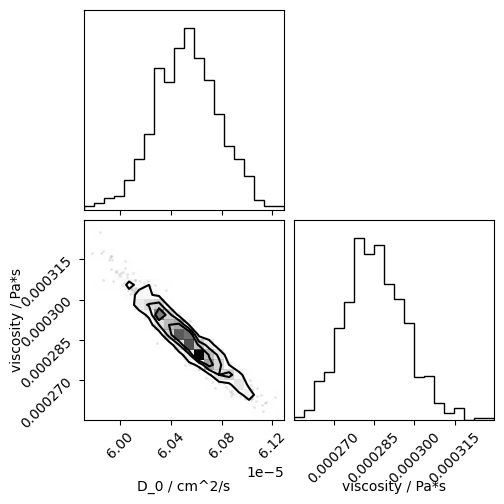

In [6]:
from corner import corner

corner(
    np.array([i.values for i in yh.flatchain.values()]).T,
    labels=[' / '.join([k, str(v.unit)]) for k, v in yh.flatchain.items()],
)
plt.show()

## Accessing the results

The infinite-system diffusion coefficient and shear viscosity are now available as probability distributions:

In [7]:
yh.D_infinite

<scipp.Variable> (samples: 800)    float64         [cm^2/s]  [6.04126e-05, 6.07504e-05, ..., 6.05378e-05, 6.0707e-05]

In [8]:
yh.shear_viscosity

<scipp.Variable> (samples: 800)    float64           [Pa*s]  [0.00029584, 0.000274112, ..., 0.000284939, 0.000282393]

## Plotting the results

We can now plot the linear relationship between the diffusion coefficient and the inverse box length with credible intervals.
For the estimation of the diffusion coefficient $D_\infty$ we extrapolate to infinite box size $\frac{1}{L} \to 0$:

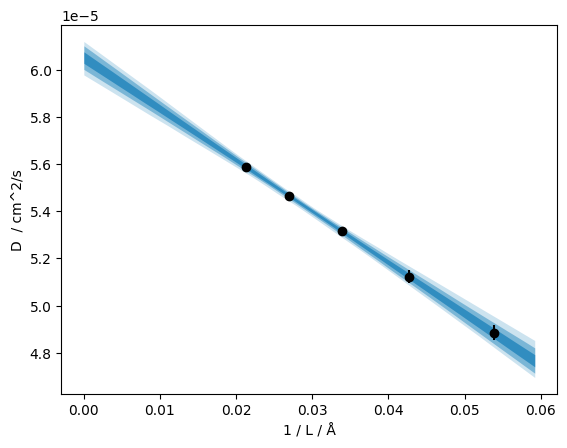

In [9]:
fig, ax = plt.subplots()

credible_intervals = [[16, 84], [2.5, 97.5], [0.15, 99.85]]
alpha = [0.6, 0.4, 0.2]

inv_L_data = 1 / yh.box_lengths.values
max_inv_L = np.max(inv_L_data)
inv_L_extended = np.linspace(0, max_inv_L * 1.1, 50)

ax.errorbar(
    inv_L_data,
    yh.diffusion.values,
    np.sqrt(yh.diffusion.variances),
    marker='o',
    ls='',
    color='k',
    zorder=10,
)

D_0_samples = yh.data_group['D_0'].values
eta_samples = yh.data_group['viscosity'].values
n_samples = len(D_0_samples)
predictions_extended = np.zeros((len(inv_L_extended), n_samples))

for i in range(len(yh.data_group['D_0'])):
    slope = yh.viscosity_to_slope(eta_samples[i] * yh.parameter_units[1])
    predictions_extended[:, i] = yh.yeh_hummer_linear(inv_L_extended, D_0_samples[i], slope)

for i, ci in enumerate(credible_intervals):
    ax.fill_between(
        inv_L_extended,
        *np.percentile(predictions_extended, ci, axis=1),
        alpha=alpha[i],
        color='#0173B2',
        lw=0,
    )

ax.set_xlabel(f'1 / L / {yh.box_lengths.unit}')
ax.set_ylabel(f'D  / {yh.diffusion.unit}')
plt.show()

## Understanding the results

The Yeh-Hummer correction provides two important quantities:

1. **Infinite-system diffusion coefficient ($D_{\infty}$)**: This is the extrapolated diffusion coefficient for an infinite system.

2. **Shear viscosity ($\eta$)**: This is estimated from the slope of the linear relationship:

$$D_{\text{PBC}} = D_\infty - \frac{k_B T \xi}{6\pi\eta L}$$

where:
- $D_{\text{PBC}}$ is the diffusion coefficient from the periodic simulation
- $D_\infty$ is the infinite-system diffusion coefficient
- $k_B$ is the Boltzmann constant
- $T$ is the temperature
- $\xi$ constant from Ewald summation (2.837297 for cubic boxes)
- $\eta$ is the shear viscosity
- $L$ is the box length